# Network structure: original → September → October

Compares the three `.bnet` revisions of the autophagy/apoptosis model, one transition at a time.

The structure of each model is its **signed regulatory graph**. AEON infers the graph from the update
functions (`infer_valid_graph`). It keeps an edge only if the regulator really affects the target,
and it reads the sign from the logic, not from the text. A rule change is called **rewired** if it
changes the target's incoming edges. It is called **logic only** if the edges stay the same but the
function changes. Rules whose text changed but whose truth table did not are ignored.

In [1]:
import itertools
import os
import re
import xml.etree.ElementTree as ET
import zipfile
from pathlib import Path

import biodivine_aeon as ba
import pandas as pd
import pygraphviz as pgv
from IPython.display import Image, display

if not Path("model").exists():          # repo root
    os.chdir("../../../../")
pd.set_option("display.max_colwidth", None)

VERSIONS = {
    "original":  Path("model/autophagy/Autophagy_and_apoptosis.bnet"),
    "september": Path("model/autophagy_september26/Autophagy_and_apoptosis_Sept26.bnet"),
    "october":   Path("model/autophagy_october26/Autophagy_and_apoptosis_Sept26_2026-10-01.bnet"),
}

In [2]:
def load(path):
    """Rules as written ({node: formula}) and signed edges ({(source, target): '+'|'-'|'±'})."""
    rules = {}
    for line in path.read_text().splitlines():
        line = line.split("#")[0].strip()
        if "," in line and not line.startswith("targets"):
            target, formula = (s.strip() for s in line.split(",", 1))
            rules[target] = formula
    bn = ba.BooleanNetwork.from_file(str(path)).infer_valid_graph()
    edges = {(bn.get_variable_name(r["source"]), bn.get_variable_name(r["target"])): r["sign"] or "±"
             for r in bn.regulations()}
    return rules, edges


def equivalent(f, g):
    """Truth-table equality of two .bnet formulas."""
    names = sorted(set(re.findall(r"[A-Za-z_]\w*", f + " " + g)))
    py = lambda s: s.replace("!", " not ").replace("&", " and ").replace("|", " or ")
    f, g = py(f), py(g)
    return all(eval(f, {}, dict(zip(names, bits))) == eval(g, {}, dict(zip(names, bits)))
               for bits in itertools.product([False, True], repeat=len(names)))


models = {v: load(p) for v, p in VERSIONS.items()}

## 1 — Size of each revision

In [3]:
def summary(rules, edges):
    signs = pd.Series(edges).value_counts()
    return {"nodes": len(rules),
            "inputs (X, X)": sum(f == n for n, f in rules.items()),
            "constants (0/1)": sum(f in {"0", "1"} for f in rules.values()),
            "edges": len(edges),
            "activating (+)": signs.get("+", 0),
            "inhibiting (−)": signs.get("-", 0),
            "non-monotone (±)": signs.get("±", 0)}

pd.DataFrame({v: summary(*m) for v, m in models.items()})

,original,september,october
nodes,119,119,125
"inputs (X, X)",6,6,7
constants (0/1),3,2,0
edges,194,199,216
activating (+),136,140,155
inhibiting (−),58,59,61
non-monotone (±),0,0,0


## 2 — What changes in each transition

`compare` returns two tables:
- **rules**: every node whose update function changed.
- **edges**: every edge that was added, removed or changed sign.

`draw` shows only the changed part of the network: the changed nodes, the endpoints of changed edges,
and the unchanged edges among them (grey) for context.

| | |
|---|---|
| edge colour | green = added, red dashed = removed, orange = sign flip (labelled old→new) |
| arrowhead | → activation, ⊣ inhibition, ● non-monotone |
| node fill | green = new node, red = removed node, yellow = rule changed |

In [4]:
def compare(old, new):
    (r0, e0), (r1, e1) = models[old], models[new]
    edges = pd.DataFrame(
        [(s, t, e0.get((s, t), ""), e1.get((s, t), "")) for s, t in sorted(set(e0) | set(e1))
         if e0.get((s, t)) != e1.get((s, t))],
        columns=["source", "target", old, new])
    edges.insert(0, "change", ["added" if not a else "removed" if not b else "sign flip"
                               for a, b in zip(edges[old], edges[new])])
    rows = []
    for n in sorted(set(r0) | set(r1), key=str.lower):
        f0, f1 = r0.get(n, ""), r1.get(n, "")
        if f0 == f1 or (f0 and f1 and equivalent(f0, f1)):
            continue
        kind = ("node added" if not f0 else "node removed" if not f1
                else "rewired" if (edges["target"] == n).any() else "logic only")
        rows.append((n, kind, f0, f1))
    rules = pd.DataFrame(rows, columns=["node", "change", old, new]).set_index("node")
    return rules, edges.sort_values(["change", "target"]).reset_index(drop=True)


ARROW = {"+": "normal", "-": "tee", "±": "dot"}
EDGE_STYLE = {"added": dict(color="#1a9850", penwidth=2),
              "removed": dict(color="#d73027", penwidth=2, style="dashed"),
              "sign flip": dict(color="#e08214", penwidth=2)}
NODE_FILL = {"node added": "#c7e9c0", "node removed": "#fcbba1", "rewired": "#fff3b0", "logic only": "#fff3b0"}


def draw(old, new, rules, edges):
    e0, e1 = models[old][1], models[new][1]
    shown = set(rules.index) | set(edges.source) | set(edges.target)
    g = pgv.AGraph(directed=True, strict=False, rankdir="LR", nodesep=0.25, ranksep=0.6)
    g.node_attr.update(shape="box", style="rounded,filled", fillcolor="white", fontname="Helvetica", fontsize=11)
    g.edge_attr.update(fontname="Helvetica", fontsize=10)
    for n in sorted(shown):
        g.add_node(n, fillcolor=NODE_FILL.get(rules["change"].get(n), "white"))
    for (s, t), sign in e1.items():          # unchanged context
        if s in shown and t in shown and e0.get((s, t)) == sign:
            g.add_edge(s, t, color="#bdbdbd", arrowhead=ARROW[sign])
    for change, s, t, a, b in edges.itertuples(index=False):
        label = f"{a}→{b}".replace("-", "−") if change == "sign flip" else ""
        g.add_edge(s, t, arrowhead=ARROW[b or a], label=label, **EDGE_STYLE[change])
    display(Image(g.draw(format="png", prog="dot", args="-Gdpi=110")))


def transition(old, new):
    rules, edges = compare(old, new)
    print(f"{old} → {new}:  rules {rules['change'].value_counts().to_dict()}   "
          f"edges {edges['change'].value_counts().to_dict()}")
    draw(old, new, rules, edges)
    return rules, edges

### 2a — original → september

original → september:  rules {'rewired': 6, 'logic only': 1}   edges {'added': 6, 'removed': 1}


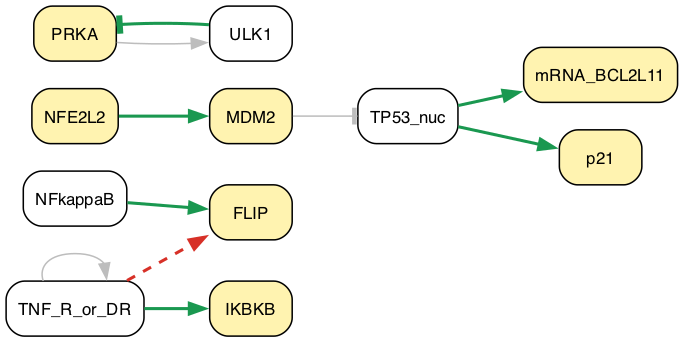

,change,original,september
node,,,
FLIP,rewired,TNF_R_or_DR,NFkappaB
IKBKB,rewired,TRAF6,!TNF_R_or_DR&TRAF6 | TNF_R_or_DR
MDM2,rewired,!ATM&AKT1,!NFE2L2&!ATM&AKT1 | NFE2L2&!ATM
mRNA_BCL2L11,rewired,CHOP,!TP53_nuc&CHOP | TP53_nuc
NFE2L2,logic only,!KEAP1 | KEAP1&!GSK3A | KEAP1&GSK3A&EIF2AK3,!KEAP1&!GSK3A&EIF2AK3
p21,rewired,0,TP53_nuc
PRKA,rewired,!Growth_factor | Growth_factor&!AA_Starvation&!STK11&CAMKKB | Growth_factor&!AA_Starvation&STK11 | Growth_factor&AA_Starvation,!Growth_factor&!ULK1 | Growth_factor&!AA_Starvation&!STK11&!ULK1&CAMKKB | Growth_factor&!AA_Starvation&STK11&!ULK1 | Growth_factor&AA_Starvation&!ULK1


In [5]:
rules_os, edges_os = transition("original", "september")
rules_os

In [6]:
edges_os

,change,source,target,original,september
0,added,NFkappaB,FLIP,,+
1,added,TNF_R_or_DR,IKBKB,,+
2,added,NFE2L2,MDM2,,+
3,added,ULK1,PRKA,,-
4,added,TP53_nuc,mRNA_BCL2L11,,+
5,added,TP53_nuc,p21,,+
6,removed,TNF_R_or_DR,FLIP,+,


- A negative feedback loop is closed: **ULK1 ⊣ PRKA**. AMPK now switches off when ULK1 is on.
- Two p53 outputs are wired in: **TP53_nuc → p21**, which replaces the constant `p21 = 0`, and
  **TP53_nuc → mRNA_BCL2L11**.
- FLIP is now induced by **NFkappaB**, not directly by TNF_R_or_DR. TNF_R_or_DR is added as a
  direct activator of IKBKB, alongside TRAF6.
- **NFE2L2 → MDM2** is added.
- NFE2L2 has the same three regulators with the same signs, but its rule changes from an OR to an
  AND: it needs `!KEAP1 & !GSK3A & EIF2AK3`. Because `KEAP1 = 0`, the old rule kept NFE2L2 always on.

### 2b — september → october

september → october:  rules {'rewired': 10, 'node added': 7, 'node removed': 1}   edges {'added': 20, 'removed': 3, 'sign flip': 2}


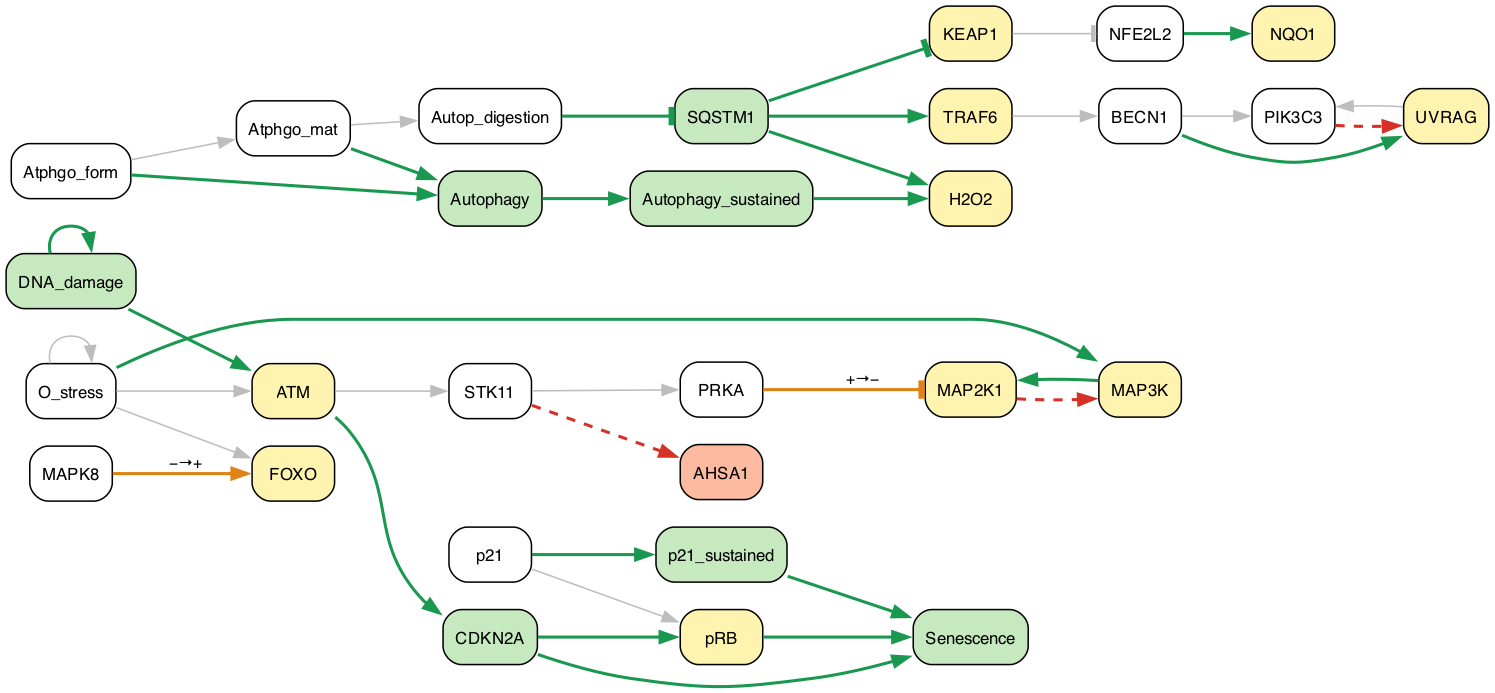

,change,september,october
node,,,
AHSA1,node removed,STK11,
ATM,rewired,O_stress,!O_stress&DNA_damage | O_stress
Autophagy,node added,,!Atphgo_form&Atphgo_mat | Atphgo_form
Autophagy_sustained,node added,,Autophagy
CDKN2A,node added,,ATM
DNA_damage,node added,,DNA_damage
FOXO,rewired,O_stress&!AKT1&!MAPK8,O_stress&!AKT1 | O_stress&AKT1&MAPK8
H2O2,rewired,!Mito_overcharge&ROMO1 | Mito_overcharge,!Mito_overcharge&!ROMO1&SQSTM1&Autophagy_sustained | !Mito_overcharge&ROMO1 | Mito_overcharge
KEAP1,rewired,0,!SQSTM1


In [7]:
rules_so, edges_so = transition("september", "october")
rules_so

In [8]:
edges_so

,change,source,target,september,october
0,added,DNA_damage,ATM,,+
1,added,Atphgo_form,Autophagy,,+
2,added,Atphgo_mat,Autophagy,,+
3,added,Autophagy,Autophagy_sustained,,+
4,added,ATM,CDKN2A,,+
5,added,DNA_damage,DNA_damage,,+
6,added,Autophagy_sustained,H2O2,,+
7,added,SQSTM1,H2O2,,+
8,added,SQSTM1,KEAP1,,-
9,added,MAP3K,MAP2K1,,+


- **New modules**:
  - Senescence: `CDKN2A`, `p21_sustained`, and the `Senescence` readout, driven by
    `pRB` / `CDKN2A` / `p21_sustained`.
  - DNA damage: `DNA_damage`, a new input, → ATM → CDKN2A.
  - p62: `SQSTM1`. It is inhibited by Autop_digestion and acts on KEAP1, TRAF6 and H2O2.
  - An `Autophagy` / `Autophagy_sustained` readout, built from Atphgo_form and Atphgo_mat.
- **AHSA1** is removed. It was a dead-end output of STK11.
- **The MAP3K–MAP2K1 edge is reversed**. MAP3K is now driven by O_stress and activates MAP2K1.
  Before, MAP2K1 activated MAP3K. PRKA's effect on MAP2K1 flips from + to −.
- **MAPK8 → FOXO** flips from − to +.
- **UVRAG** is now activated by BECN1, not PIK3C3.
- **KEAP1 and NQO1 are no longer constants**. KEAP1 = `!SQSTM1` and NQO1 = `NFE2L2`. The shared
  scenario convention pins both to 1 at t = 0. In October that is only an initial condition, not a
  fixed input.

## 3 — Whole-network overview

All three revisions drawn on **one shared layout**: the curated node positions from the GINsim
`.zginml` files (the newest file wins where a node was nudged). A node sits in the same place in
every panel, and every panel has the same canvas, so the panels can be compared by eye.

Highlights are **cumulative**. An edge or node keeps the colour of the revision that introduced it,
so in the October panel the September additions are still blue and the October additions are green.
Red dashed items are what a revision removed from the one before it.

Four positions are set by hand because the GINsim file stacks nodes on top of each other:
`Autophagy_sustained` (left at GINsim's default (0, 0)), `DNA_damage` (placed on KEAP1), `CDKN2A`
(touching STK11) and `AHSA1` (its old spot is now CDKN2A's).

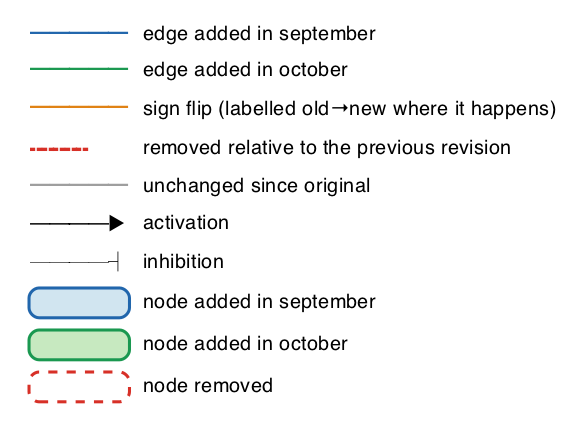

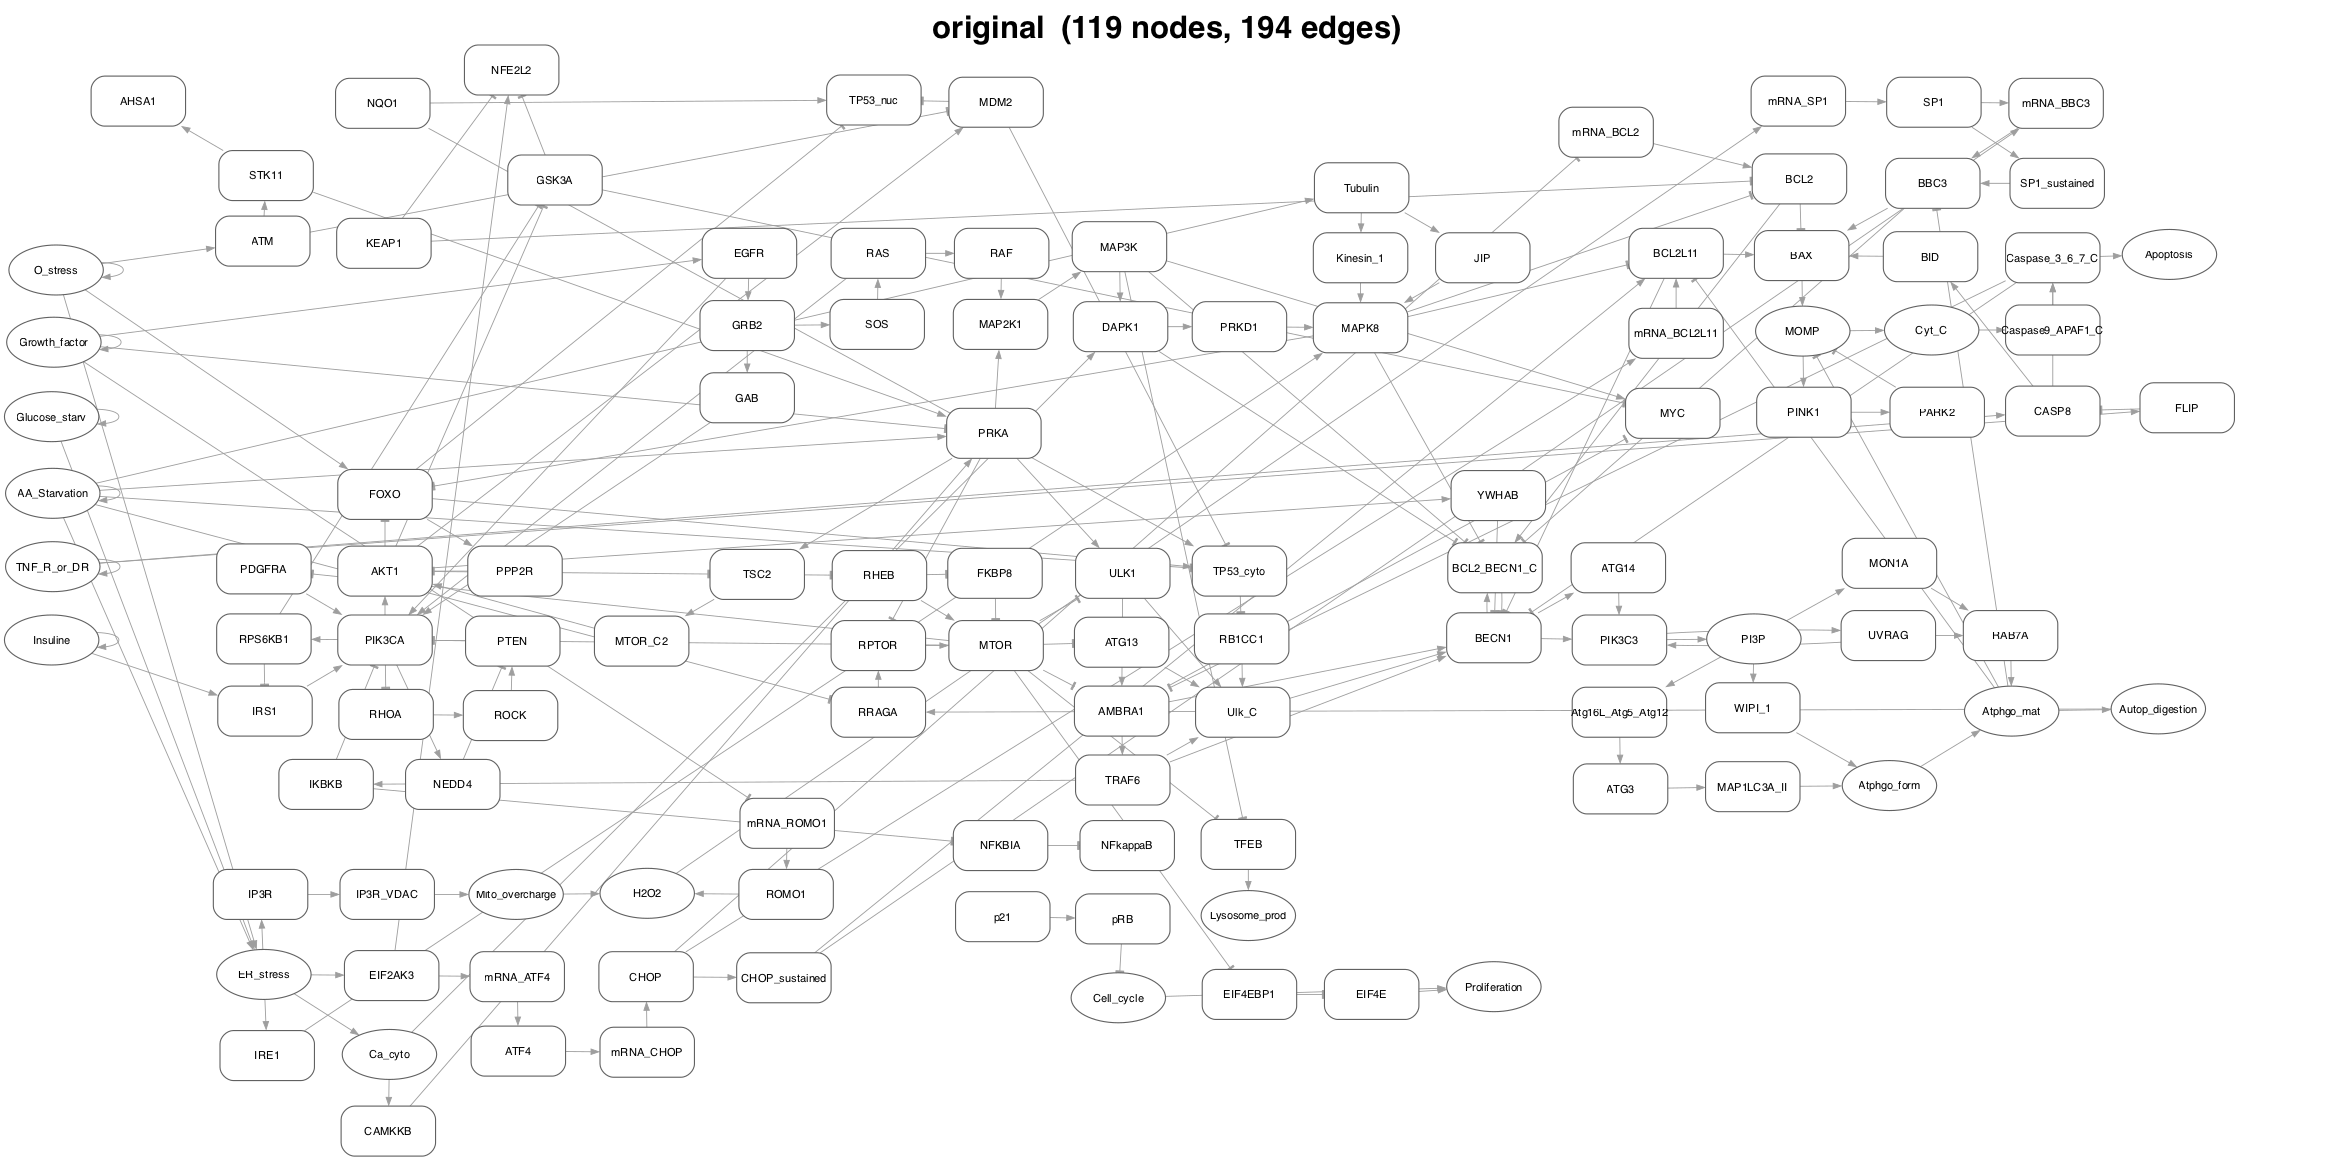

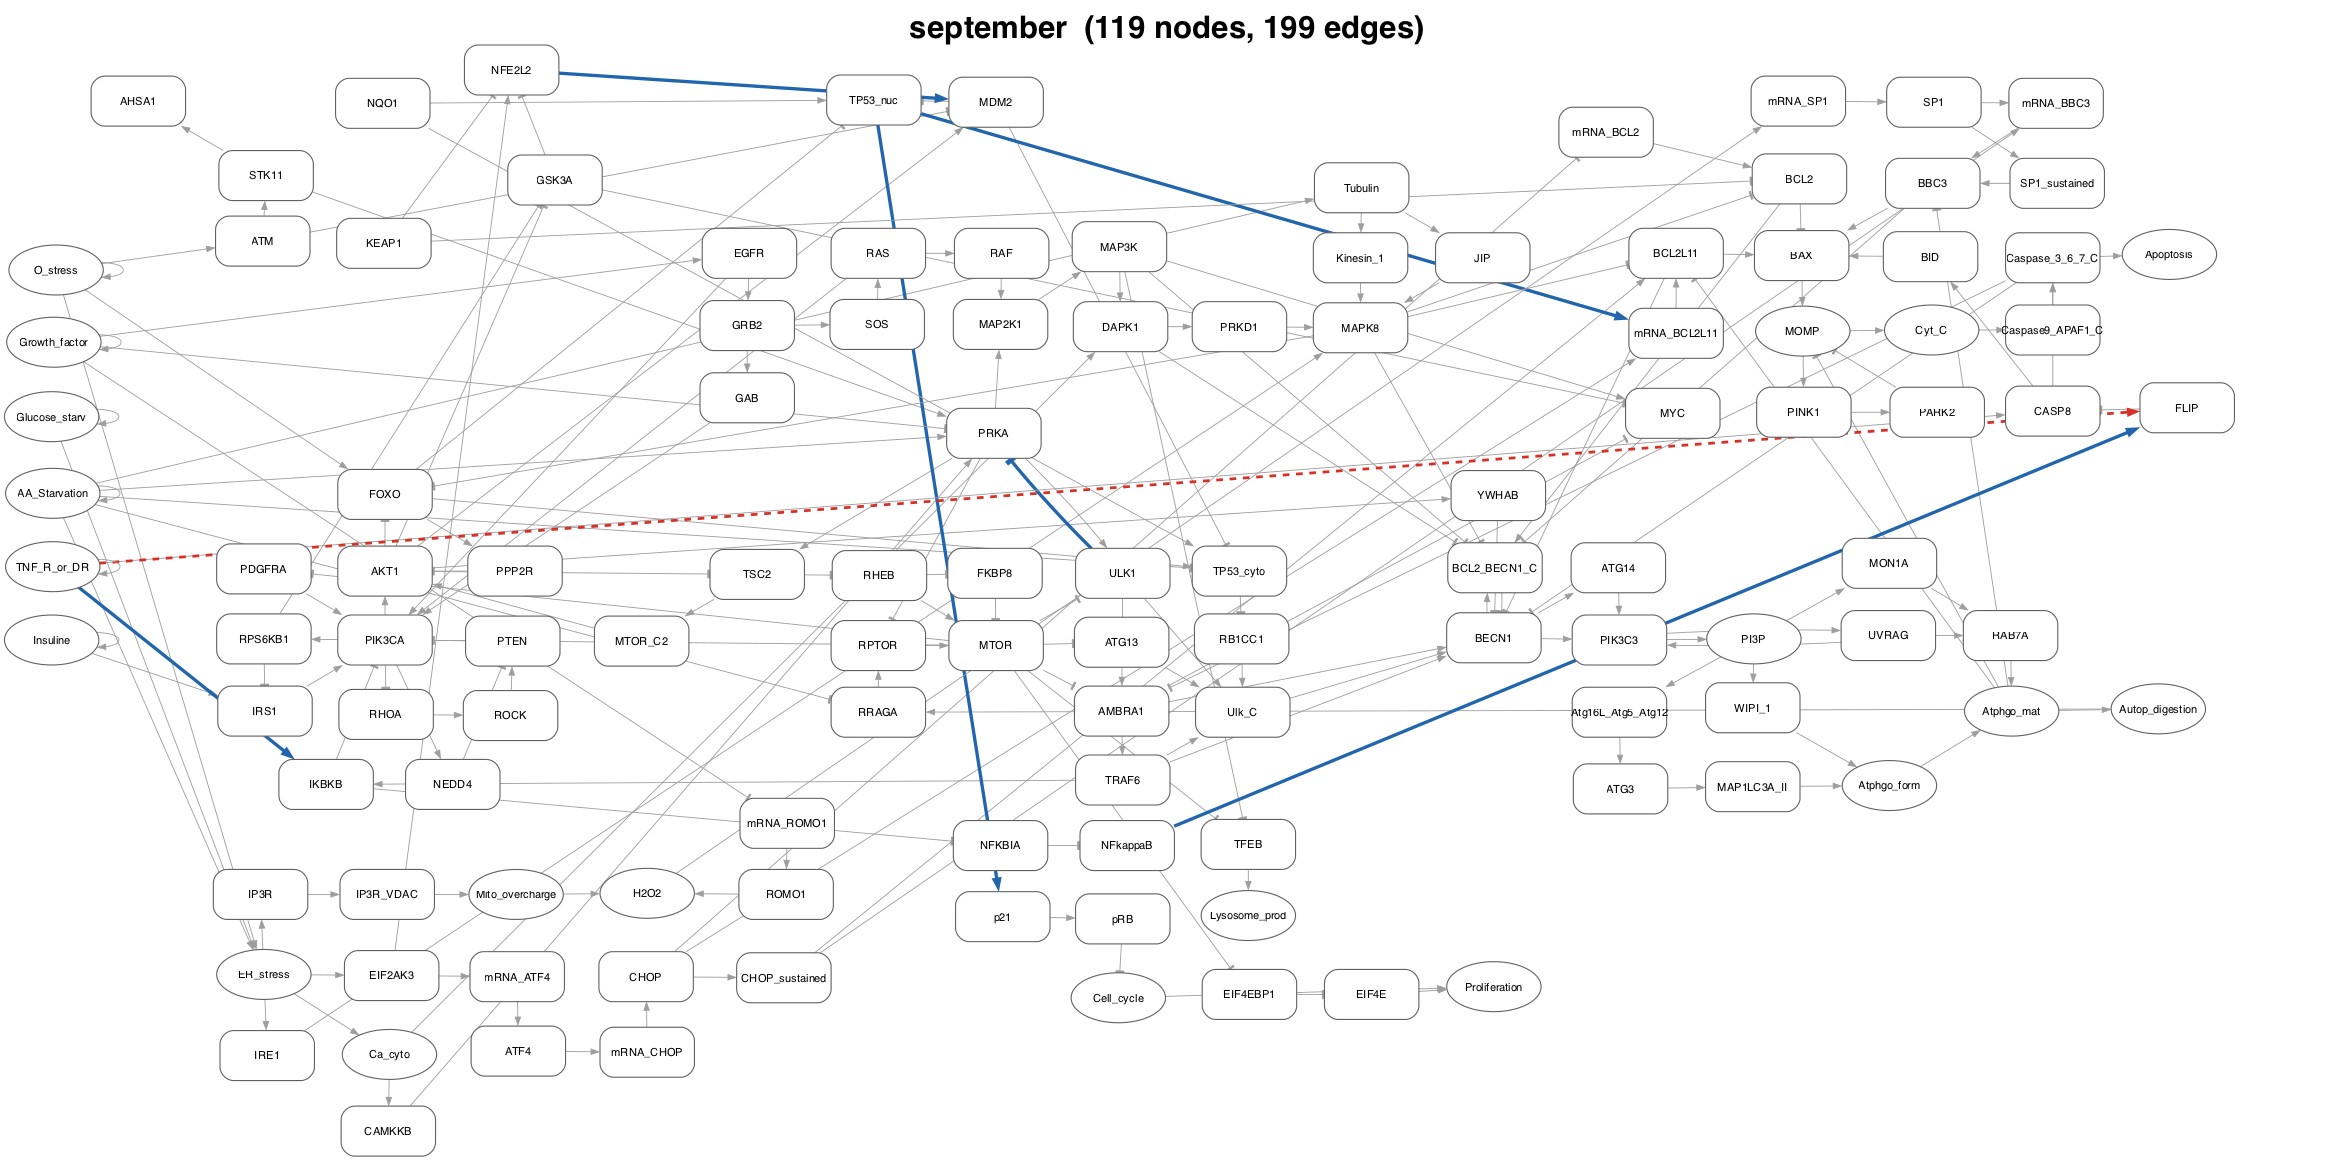

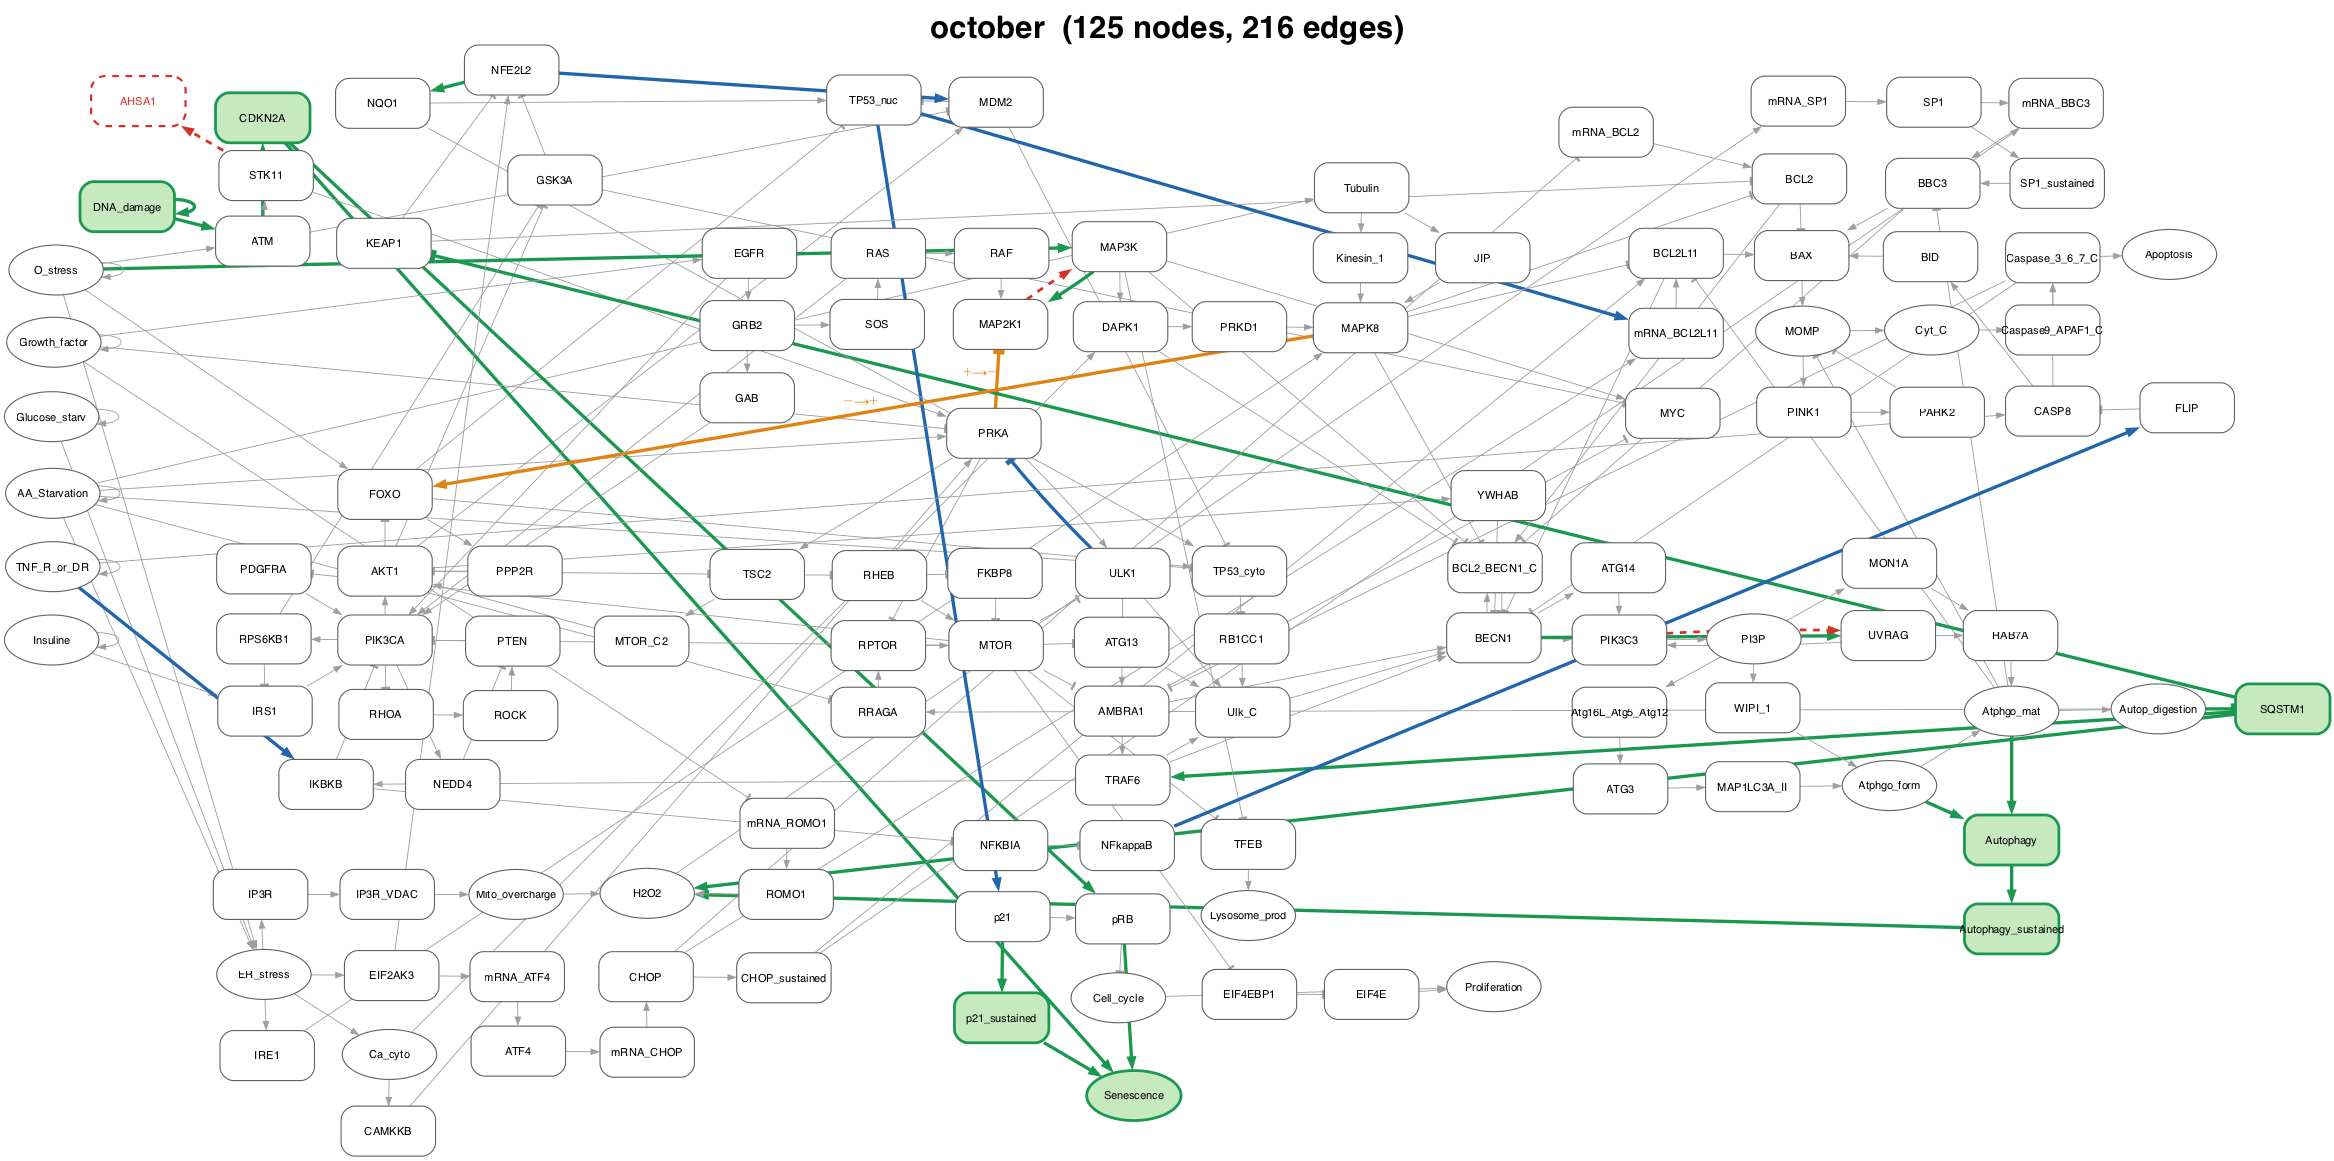

In [9]:
def ginsim_layout(path):
    """Curated node positions from a GINsim .zginml: {node: (x, y, style)}."""
    root = ET.fromstring(zipfile.ZipFile(path).read("GINsim-data/regulatoryGraph.ginml"))
    return {n.get("id"): (float(v.get("x")), float(v.get("y")), v.get("style") or "")
            for n in root.iter("node") for v in n.iter("nodevisualsetting")}


# one position per node across all revisions; the newest file wins for shared nodes
LAYOUT = {}
for p in VERSIONS.values():
    LAYOUT.update(ginsim_layout(next(p.parent.glob("*.zginml"))))
# manual fixes where the GINsim file stacks nodes on top of each other
LAYOUT["Autophagy_sustained"] = (1806, 780, "")       # left at GINsim's default (0, 0)
LAYOUT["DNA_damage"] = (110, 130, "")                 # placed on KEAP1 (341, 163)
LAYOUT["CDKN2A"] = (232, 50, "")                      # touched STK11
LAYOUT["AHSA1"] = (120, 35, "Temporary input/output")  # its old spot is now CDKN2A's

ADDED_IN = {"september": "#2166ac", "october": "#1a9850"}   # colour = revision that introduced it
NODE_ADDED_FILL = {"september": "#d1e5f0", "october": "#c7e9c0"}
FLIP, REMOVED, BASE = "#e08214", "#d73027", "#9e9e9e"
ROUND = {"Input", "Phenomenons", "True_output", "Metabolite"}


def history(kind):
    """{version: {item: status}}, status = ('base' | 'added' | 'flip', version it changed in).
    kind='edges' tracks signed edges, kind='nodes' tracks nodes. A status persists while the item is unchanged."""
    out, prev, prev_status = {}, None, {}
    for v, (rules, edges) in models.items():
        items = edges if kind == "edges" else dict.fromkeys(rules)
        status = {}
        for k, val in items.items():
            if prev is None:
                status[k] = ("base", v)
            elif k not in prev:
                status[k] = ("added", v)
            elif prev[k] != val:
                status[k] = ("flip", v)
            else:
                status[k] = prev_status[k]
        out[v], prev, prev_status = status, items, status
    return out


EDGE_HIST, NODE_HIST = history("edges"), history("nodes")


def overview(version):
    """Whole network of one revision on the shared layout, with additions highlighted cumulatively
    and what this revision removed from the previous one drawn as red dashed ghosts."""
    names = list(models)
    prev = names[names.index(version) - 1] if names.index(version) else None
    rules, edges = models[version]
    old_rules, old_edges = models[prev] if prev else ({}, {})

    g = pgv.AGraph(directed=True, strict=False, splines="line", outputorder="edgesfirst",
                   label=f"{version}  ({len(rules)} nodes, {len(edges)} edges)", labelloc="t", fontsize=28,
                   fontname="Helvetica-Bold")
    g.node_attr.update(fontname="Helvetica", fontsize=10, width=85 / 72, height=45 / 72,
                       fixedsize="shape", style="rounded,filled", penwidth=1)
    g.edge_attr.update(arrowsize=0.7)

    def add_node(n, **kw):
        x, y, style = LAYOUT[n]
        g.add_node(n, pos=f"{x},{-y}!", shape="ellipse" if style in ROUND else "box", **kw)

    # invisible corners at the extent of the union layout, so every panel has the same canvas
    xs, ys = [p[0] for p in LAYOUT.values()], [p[1] for p in LAYOUT.values()]
    for i, (x, y) in enumerate([(min(xs), min(ys)), (max(xs), max(ys))]):
        g.add_node(f"_corner{i}", pos=f"{x},{-y}!", style="invis", label="")
    for n in rules:
        kind, since = NODE_HIST[version][n]
        if kind == "added":
            add_node(n, fillcolor=NODE_ADDED_FILL[since], color=ADDED_IN[since], penwidth=2.5)
        else:
            add_node(n, fillcolor="white", color="#616161")
    for n in set(old_rules) - set(rules):
        add_node(n, fillcolor="white", color=REMOVED, fontcolor=REMOVED, style="rounded,dashed", penwidth=2)

    # grey baseline first so highlighted edges are drawn on top
    ranked = sorted(edges.items(), key=lambda kv: EDGE_HIST[version][kv[0]][0] != "base")
    for (s, t), sign in ranked:
        kind, since = EDGE_HIST[version][(s, t)]
        style = dict(color=BASE, penwidth=0.8)
        if kind == "added":
            style = dict(color=ADDED_IN[since], penwidth=3)
        elif kind == "flip":
            style = dict(color=FLIP, penwidth=3)
            if since == version:
                style["label"] = f"{old_edges[(s, t)]}→{sign}".replace("-", "−")
                style.update(fontcolor=FLIP, fontsize=14)
        g.add_edge(s, t, arrowhead=ARROW[sign], **style)
    for (s, t), sign in old_edges.items():
        if (s, t) not in edges:
            g.add_edge(s, t, arrowhead=ARROW[sign], color=REMOVED, penwidth=2.5, style="dashed")
    return g


def legend():
    line = lambda colour, glyph="━━━━━": f'<font color="{colour}">{glyph}</font>'
    box = lambda fill, border, dashed="": (f'<td bgcolor="{fill}" color="{border}" border="2" '
                                           f'style="rounded{dashed}" width="60"> </td>')
    rows = [(line(ADDED_IN["september"]), "edge added in september"),
            (line(ADDED_IN["october"]), "edge added in october"),
            (line(FLIP), "sign flip (labelled old→new where it happens)"),
            (line(REMOVED, "╍╍╍╍╍"), "removed relative to the previous revision"),
            (line(BASE), "unchanged since original"),
            (line("black", "────▶"), "activation"),
            (line("black", "────┤"), "inhibition")]
    cells = "".join(f'<tr><td align="left">{g}</td><td align="left">{t}</td></tr>' for g, t in rows)
    cells += "".join(f'<tr>{box(NODE_ADDED_FILL[v], ADDED_IN[v])}<td align="left">node added in {v}</td></tr>'
                     for v in ADDED_IN)
    cells += f'<tr>{box("white", REMOVED, ",dashed")}<td align="left">node removed</td></tr>'
    g = pgv.AGraph()
    g.add_node("legend", shape="plaintext", fontname="Helvetica", fontsize=13,
               label=f'<<table border="0" cellspacing="6">{cells}</table>>')
    return g


display(Image(legend().draw(format="png", prog="dot", args="-Gdpi=110")))
for v in models:
    display(Image(overview(v).draw(format="png", prog="neato", args="-n2 -Gdpi=80")))
